# Time-RCD: эксперименты с маскированием


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    mean_squared_error, mean_absolute_error
)
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import os, copy


from timercd_model import build_timercd, TimeRCD

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

D:\anaconda3\envs\moment-anomaly\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 1. Загрузка данных

In [3]:
import os
import numpy as np

base = r"C:\Users\Анастасия\moment\DiffusionAE\DiffusionAE\processed"
dataset_names = ["pattern_seasonal", "pattern_shapelet", "pattern_trendv2", 
                 "point_contextual", "point_global"]

all_train, all_test, all_labels = [], [], []

for name in dataset_names:
    path = os.path.join(base, name)
    train = np.load(os.path.join(path, "train.npy"))
    test  = np.load(os.path.join(path, "test.npy"))
    labs  = np.load(os.path.join(path, "labels.npy"))
    all_train.append(train)
    all_test.append(test)
    all_labels.append(labs)
    print(f"  {name}: train={train.shape}, test={test.shape}, anomalies={labs.mean()*100:.1f}%")

train_data = np.concatenate(all_train, axis=0) 
test_data  = np.concatenate(all_test,  axis=0)  
labels     = np.concatenate(all_labels, axis=0) 

print(f"\nИтого: train={train_data.shape}, test={test_data.shape}")
N_CHANNELS = train_data.shape[1]

train_norm_parts, test_norm_parts = [], []
for tr, te in zip(all_train, all_test):
    mean = tr.mean(axis=0, keepdims=True)
    std  = tr.std(axis=0,  keepdims=True) + 1e-8
    train_norm_parts.append((tr - mean) / std)
    test_norm_parts.append( (te - mean) / std)

train_norm = np.concatenate(train_norm_parts, axis=0)
test_norm  = np.concatenate(test_norm_parts,  axis=0)

if labels.ndim == 2:
    point_labels = (labels.mean(axis=1) > 0.5).astype(int)
else:
    point_labels = labels.astype(int)

print(f"Аномалий суммарно: {point_labels.sum()} ({point_labels.mean()*100:.2f}%)")

  pattern_seasonal: train=(20000, 5), test=(20000, 5), anomalies=6.8%
  pattern_shapelet: train=(20000, 5), test=(20000, 5), anomalies=6.8%
  pattern_trendv2: train=(20000, 5), test=(20000, 5), anomalies=4.7%
  point_contextual: train=(20000, 5), test=(20000, 5), anomalies=5.7%
  point_global: train=(20000, 5), test=(20000, 5), anomalies=5.7%

Итого: train=(100000, 5), test=(100000, 5)
Аномалий суммарно: 5933 (5.93%)


## 2. Dataset и DataLoader

In [4]:
WINDOW_SIZE = 512   
STRIDE      = 32

class TSWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, window_size: int, stride: int):
        self.data        = torch.from_numpy(data).float()   # (T, C)
        self.window_size = window_size
        self.stride      = stride

    def __len__(self):
        return (self.data.shape[0] - self.window_size) // self.stride + 1

    def __getitem__(self, idx):
        start = idx * self.stride
        return self.data[start : start + self.window_size] 


train_dataset = TSWindowDataset(train_norm, WINDOW_SIZE, STRIDE)
test_dataset  = TSWindowDataset(test_norm,  WINDOW_SIZE, STRIDE)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=0)

print(f"Обучающих окон:  {len(train_dataset)}")
print(f"Тестовых окон:   {len(test_dataset)}")
print(f"Форма батча:     {next(iter(train_loader)).shape}")

Обучающих окон:  3110
Тестовых окон:   3110
Форма батча:     torch.Size([16, 512, 5])


## 3. Вспомогательные функции

In [5]:
@torch.no_grad()
def get_reconstructions(loader, model, device):
    model.eval()
    all_orig  = []
    all_recon = []
    for batch in tqdm(loader, desc="Inference", leave=False):
        batch = batch.to(device)
        out   = model(batch)          # ← обычный forward, без маски!
        all_orig.append(batch.cpu())
        all_recon.append(out.reconstruction.cpu())
    return torch.cat(all_orig), torch.cat(all_recon)


def windows_to_timeseries(windows, full_length, window_size, stride):
    N, W, C = windows.shape
    output = np.zeros((full_length, C))
    count  = np.zeros((full_length, C))
    for i in range(N):
        start = i * stride
        end   = start + W
        if end > full_length:
            break
        output[start:end] += windows[i]
        count[start:end]  += 1
    return output / np.maximum(count, 1)


def compute_metrics(point_labels, point_errors):
    roc_auc = roc_auc_score(point_labels, point_errors)

    best = dict(f1=0, precision=0, recall=0, threshold=0)
    for perc in np.arange(80, 100, 0.5):
        th   = np.percentile(point_errors, perc)
        pred = (point_errors > th).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(
            point_labels, pred, average='binary', zero_division=0
        )
        if f1 > best['f1']:
            best = dict(f1=f1, precision=p, recall=r, threshold=th)

    return dict(roc_auc=roc_auc, **best)


def compute_recon_metrics(orig_ts, recon_ts):
    rmse = np.sqrt(mean_squared_error(orig_ts, recon_ts))
    mae  = mean_absolute_error(orig_ts, recon_ts)
    return dict(rmse=rmse, mae=mae)


def evaluate(model, test_loader, test_norm, point_labels, window_size, stride, device):
    full_length = test_norm.shape[0]

    origs, recons = get_reconstructions(test_loader, model, device)
    origs_np  = origs.numpy()   
    recons_np = recons.numpy()

    orig_ts  = windows_to_timeseries(origs_np,  full_length, window_size, stride)
    recon_ts = windows_to_timeseries(recons_np, full_length, window_size, stride)

    point_errors = np.abs(orig_ts - recon_ts).mean(axis=1)  

    det_metrics   = compute_metrics(point_labels, point_errors)
    recon_metrics = compute_recon_metrics(orig_ts, recon_ts)

    return {**det_metrics, **recon_metrics}

In [6]:
@torch.no_grad()
def get_reconstructions_masked(loader, model, device, eval_mask_ratio=0.3, n_runs=5):
    model.eval()
    all_orig, all_scores = [], []

    for batch in tqdm(loader, desc="Inference", leave=False):
        batch = batch.to(device)          # (B, W, C)
        B, W, C = batch.shape

        batch_scores = torch.zeros(B, W, device=device)

        for _ in range(n_runs):
            from timercd_model import apply_mask_to_patches, Patchify
            
            x_norm, stats = model.revin(batch, "norm")
            patches = model.patchify(x_norm)          # (B, N, C*P)
            
            from timercd_model import apply_mask_to_patches
            masked_patches, mask = apply_mask_to_patches(
                patches, eval_mask_ratio, "random", n_channels=C
            )
            
            encoded = model._encode(masked_patches)
            recon_patches = model.head(encoded)
            recon_norm = model.unpatchify(recon_patches)
            recon = model.revin(recon_norm, "denorm", stats=stats)
            
            scores_run = torch.abs(batch - recon).mean(dim=-1)  # (B, W)
            batch_scores += scores_run

        batch_scores /= n_runs
        all_orig.append(batch.cpu())
        all_scores.append(batch_scores.cpu())

    return torch.cat(all_orig), torch.cat(all_scores)   # (N, W, C), (N, W)

## 4. Эксперименты: mask_ratio × mask_type

In [6]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

results = []
mask_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]  
mask_type = "random"

print("=== Улучшенные эксперименты: случайное маскирование ===")
print("30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка\n")

for ratio in mask_ratios:
    print(f"\n{'='*80}")
    print(f"Обучение с mask_ratio = {ratio*100:.0f}%  (mask_type={mask_type})")
    print('='*80)
    
    model = build_timercd(
        n_channels=N_CHANNELS, 
        seq_len=WINDOW_SIZE, 
        size="medium",          
        mask_type=mask_type,
        device=str(device)
    )
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)
    
    best_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    max_patience = 8  
    
    torch.manual_seed(42 + int(ratio*100))  
    
    for epoch in range(30):   
        model.train()
        total_loss = 0.0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1:2d}", leave=False):
            batch = batch.to(device)
            
            loss = model.compute_loss(batch, mask_ratio=ratio, mask_type=mask_type)
            
            optimizer.zero_grad()
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        metrics = evaluate(model, test_loader, test_norm, point_labels, 
                           WINDOW_SIZE, STRIDE, device)
        
        scheduler.step(avg_loss)  
        
        current_f1 = metrics['f1']
        
        print(f"Epoch {epoch+1:2d} | loss={avg_loss:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"F1={current_f1:.4f} (P={metrics['precision']:.4f}, R={metrics['recall']:.4f}) | "
              f"RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")
        
        if current_f1 > best_f1 + 1e-4:
            best_f1 = current_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"   >>> Новая лучшая F1: {best_f1:.4f} <<<")
        else:
            patience_counter += 1
        
        if patience_counter >= max_patience:
            print(f"   Ранняя остановка на эпохе {epoch+1} (F1 не улучшался {max_patience} эпох)")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    final_metrics = evaluate(model, test_loader, test_norm, point_labels, 
                             WINDOW_SIZE, STRIDE, device)
    
    save_path = f"models/timercd_{mask_type}_ratio{int(ratio*100):02d}.pth"
    torch.save(model.state_dict(), save_path)
    
    res = {
        'mask_type': mask_type,
        'mask_ratio': ratio,
        'epoch_best': epoch + 1 - patience_counter,
        **final_metrics
    }
    results.append(res)
    
    print(f"Готово для ratio={ratio:.2f} → best F1={final_metrics['f1']:.4f}, ROC-AUC={final_metrics['roc_auc']:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df.to_csv("results/timercd_random_improved_results.csv", index=False)
print("Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results.csv")

=== Улучшенные эксперименты: случайное маскирование ===
30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка


Обучение с mask_ratio = 0%  (mask_type=random)


Epoch  1 | loss=0.1311 | ROC-AUC=0.9123 | F1=0.7127 (P=0.8262, R=0.6267) | RMSE=0.1323 | MAE=0.0693 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7127 <<<


Epoch  2 | loss=0.0536 | ROC-AUC=0.9129 | F1=0.7242 (P=0.8396, R=0.6368) | RMSE=0.1283 | MAE=0.0674 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7242 <<<


Epoch  3 | loss=0.0381 | ROC-AUC=0.9132 | F1=0.7263 (P=0.8420, R=0.6386) | RMSE=0.1257 | MAE=0.0663 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7263 <<<


Epoch  4 | loss=0.0290 | ROC-AUC=0.9099 | F1=0.7237 (P=0.8389, R=0.6363) | RMSE=0.1240 | MAE=0.0657 | lr=1.00e-04


...

Epoch  6 | loss=0.7129 | ROC-AUC=0.5786 | F1=0.1547 (P=0.2303, R=0.1165) | RMSE=1.6278 | MAE=1.4436 | lr=1.00e-04


Epoch  7 | loss=0.6649 | ROC-AUC=0.5717 | F1=0.1762 (P=0.2374, R=0.1401) | RMSE=1.4522 | MAE=1.2900 | lr=1.00e-04


Epoch  8 | loss=0.6185 | ROC-AUC=0.6612 | F1=0.2245 (P=0.2074, R=0.2447) | RMSE=0.8309 | MAE=0.7219 | lr=1.00e-04


Epoch  9 | loss=0.5696 | ROC-AUC=0.6923 | F1=0.3006 (P=0.3733, R=0.2516) | RMSE=0.7735 | MAE=0.6706 | lr=1.00e-04
   Ранняя остановка на эпохе 9 (F1 не улучшался 8 эпох)


Готово для ratio=0.80 → best F1=0.4016, ROC-AUC=0.6747

Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results.csv


In [9]:
results_df

,mask_type,mask_ratio,epoch_best,roc_auc,f1,precision,recall,threshold,rmse,mae
0,block,0.0,3,0.9143,0.7254,0.8409,0.6378,0.1232,0.1252,0.0663
1,block,0.2,28,0.6797,0.4255,0.7176,0.3024,1.0763,0.9907,0.8780
2,block,0.4,30,0.8727,0.5653,0.5622,0.5685,0.1973,0.1962,0.1094
3,block,0.6,15,0.6811,0.4219,0.7116,0.2998,1.0734,0.9881,0.8744
4,block,0.8,7,0.6758,0.4087,0.8105,0.2732,1.0839,0.9883,0.8745


## 5. Визуализация результатов

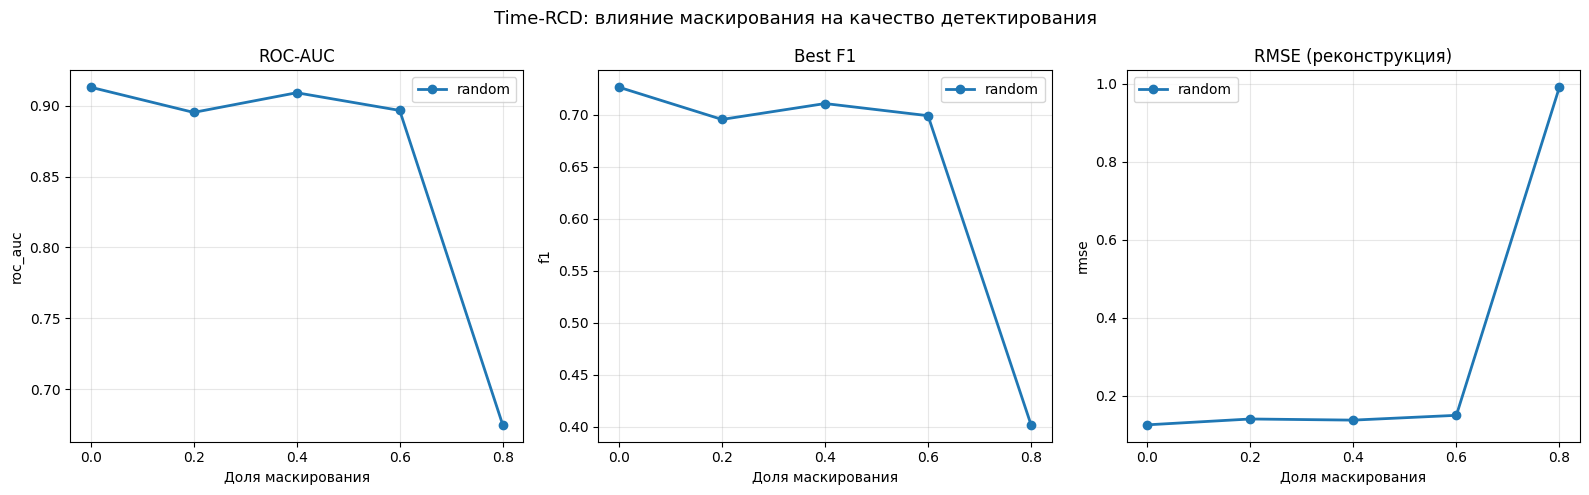

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['roc_auc', 'f1', 'rmse']
titles = ['ROC-AUC', 'Best F1', 'RMSE (реконструкция)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for mask_type, group in results_df.groupby('mask_type'):
        ax.plot(group['mask_ratio'], group[metric], 'o-', label=mask_type, linewidth=2)
    ax.set_xlabel('Доля маскирования')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(results_df['mask_ratio'].unique())

plt.suptitle('Time-RCD: влияние маскирования на качество детектирования', fontsize=13)
plt.tight_layout()
plt.show()

## Блочное маскирование

In [7]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

results = []
mask_ratios = [0.0, 0.2, 0.4, 0.6, 0.8]  
mask_type = "block"

print("=== Улучшенные эксперименты: случайное маскирование ===")
print("30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка\n")

for ratio in mask_ratios:
    print(f"\n{'='*80}")
    print(f"Обучение с mask_ratio = {ratio*100:.0f}%  (mask_type={mask_type})")
    print('='*80)
    
    model = build_timercd(
        n_channels=N_CHANNELS, 
        seq_len=WINDOW_SIZE, 
        size="medium",         
        mask_type=mask_type,
        device=str(device)
    )
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6)
    
    best_f1 = 0.0
    best_model_state = None
    patience_counter = 0
    max_patience = 8  
    
    torch.manual_seed(42 + int(ratio*100)) 
    
    for epoch in range(30): 
        model.train()
        total_loss = 0.0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1:2d}", leave=False):
            batch = batch.to(device)
            
            loss = model.compute_loss(batch, mask_ratio=ratio, mask_type=mask_type)
            
            optimizer.zero_grad()
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        metrics = evaluate(model, test_loader, test_norm, point_labels, 
                           WINDOW_SIZE, STRIDE, device)
        
        scheduler.step(avg_loss)  
        
        current_f1 = metrics['f1']
        
        print(f"Epoch {epoch+1:2d} | loss={avg_loss:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"F1={current_f1:.4f} (P={metrics['precision']:.4f}, R={metrics['recall']:.4f}) | "
              f"RMSE={metrics['rmse']:.4f} | MAE={metrics['mae']:.4f} | lr={optimizer.param_groups[0]['lr']:.2e}")
        
        if current_f1 > best_f1 + 1e-4:
            best_f1 = current_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"   >>> Новая лучшая F1: {best_f1:.4f} <<<")
        else:
            patience_counter += 1
        
        if patience_counter >= max_patience:
            print(f"   Ранняя остановка на эпохе {epoch+1} (F1 не улучшался {max_patience} эпох)")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    final_metrics = evaluate(model, test_loader, test_norm, point_labels, 
                             WINDOW_SIZE, STRIDE, device)
    
    save_path = f"models/timercd_{mask_type}_ratio{int(ratio*100):02d}.pth"
    torch.save(model.state_dict(), save_path)
    
    res = {
        'mask_type': mask_type,
        'mask_ratio': ratio,
        'epoch_best': epoch + 1 - patience_counter,
        **final_metrics
    }
    results.append(res)
    
    print(f"Готово для ratio={ratio:.2f} → best F1={final_metrics['f1']:.4f}, ROC-AUC={final_metrics['roc_auc']:.4f}\n")

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df.to_csv("results/timercd_random_improved_results_block.csv", index=False)
print("Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results_block.csv")

=== Улучшенные эксперименты: случайное маскирование ===
30 эпох + ReduceLROnPlateau + gradient clipping + ранняя остановка


Обучение с mask_ratio = 0%  (mask_type=block)


Epoch  1 | loss=0.1250 | ROC-AUC=0.9116 | F1=0.7124 (P=0.8258, R=0.6263) | RMSE=0.1322 | MAE=0.0696 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7124 <<<


Epoch  2 | loss=0.0520 | ROC-AUC=0.9133 | F1=0.7204 (P=0.7876, R=0.6637) | RMSE=0.1283 | MAE=0.0680 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7204 <<<


Epoch  3 | loss=0.0356 | ROC-AUC=0.9143 | F1=0.7254 (P=0.8409, R=0.6378) | RMSE=0.1252 | MAE=0.0663 | lr=1.00e-04
   >>> Новая лучшая F1: 0.7254 <<<


Epoch  4 | loss=0.0277 | ROC-AUC=0.9129 | F1=0.7248 (P=0.8402, R=0.6373) | RMSE=0.1234 | MAE=0.0655 | lr=1.00e-04


...

Epoch 12 | loss=0.6101 | ROC-AUC=0.6732 | F1=0.4039 (P=0.8010, R=0.2700) | RMSE=0.9869 | MAE=0.8729 | lr=1.00e-04


Epoch 13 | loss=0.5825 | ROC-AUC=0.6736 | F1=0.4036 (P=0.8005, R=0.2698) | RMSE=0.9876 | MAE=0.8735 | lr=1.00e-04


Epoch 14 | loss=0.5559 | ROC-AUC=0.6728 | F1=0.4041 (P=0.8015, R=0.2702) | RMSE=0.9870 | MAE=0.8729 | lr=1.00e-04


Epoch 15 | loss=0.5300 | ROC-AUC=0.6726 | F1=0.4041 (P=0.8015, R=0.2702) | RMSE=0.9874 | MAE=0.8734 | lr=1.00e-04
   Ранняя остановка на эпохе 15 (F1 не улучшался 8 эпох)


Готово для ratio=0.80 → best F1=0.4087, ROC-AUC=0.6758

Все эксперименты завершены! Таблица сохранена в results/timercd_random_improved_results_block.csv


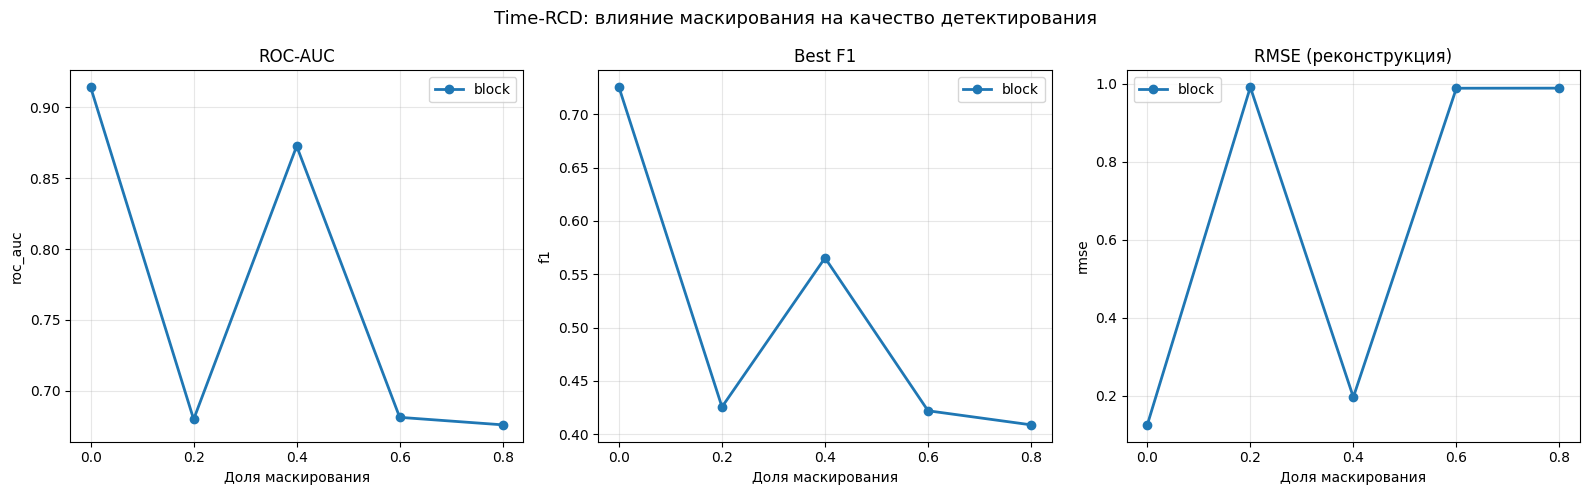

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_to_plot = ['roc_auc', 'f1', 'rmse']
titles = ['ROC-AUC', 'Best F1', 'RMSE (реконструкция)']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    for mask_type, group in results_df.groupby('mask_type'):
        ax.plot(group['mask_ratio'], group[metric], 'o-', label=mask_type, linewidth=2)
    ax.set_xlabel('Доля маскирования')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(results_df['mask_ratio'].unique())

plt.suptitle('Time-RCD: влияние маскирования на качество детектирования', fontsize=13)
plt.tight_layout()
plt.show()